# Trabajo Práctico N°3: Redes Neuronales

Aclaración: Mi computadora no soportó el peso del proyecto, por falta de RAM. Así que trabajé en Google Colab, usando distinto sistema de import para los archivos del trabajo. De todas formas, dejo el notebook como venía trabajando en los otros trabajos prácticos, pero no pude verificar que corra en VSCode. Si hay algún problema respecto a esto, por favor notificarlo.

In [ ]:
import sys
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cupy as cp
import torch
import importlib
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

simple = importlib.import_module('MLP_simple')
MLP = simple.MLP
advanced = importlib.import_module('MLP_advanced')
metrics = importlib.import_module('metrics')
grid_search_ = importlib.import_module('grid_search')
pytorch = importlib.import_module('pytorch')
utils = importlib.import_module('utils')
data_split = importlib.import_module('data_splitting')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Módulos principales del repositorio importados con éxito con importlib.
Módulos opcionales procesados.


## 1. Análisis y Preprocesamiento de Datos

In [4]:
X_images = np.load("X_images.npy")
y_images = np.load("y_images.npy")
print(f"Datos cargados: X_images {X_images.shape}, y_images {y_images.shape}")

Datos cargados: X_images (809555, 28, 28), y_images (809555,)


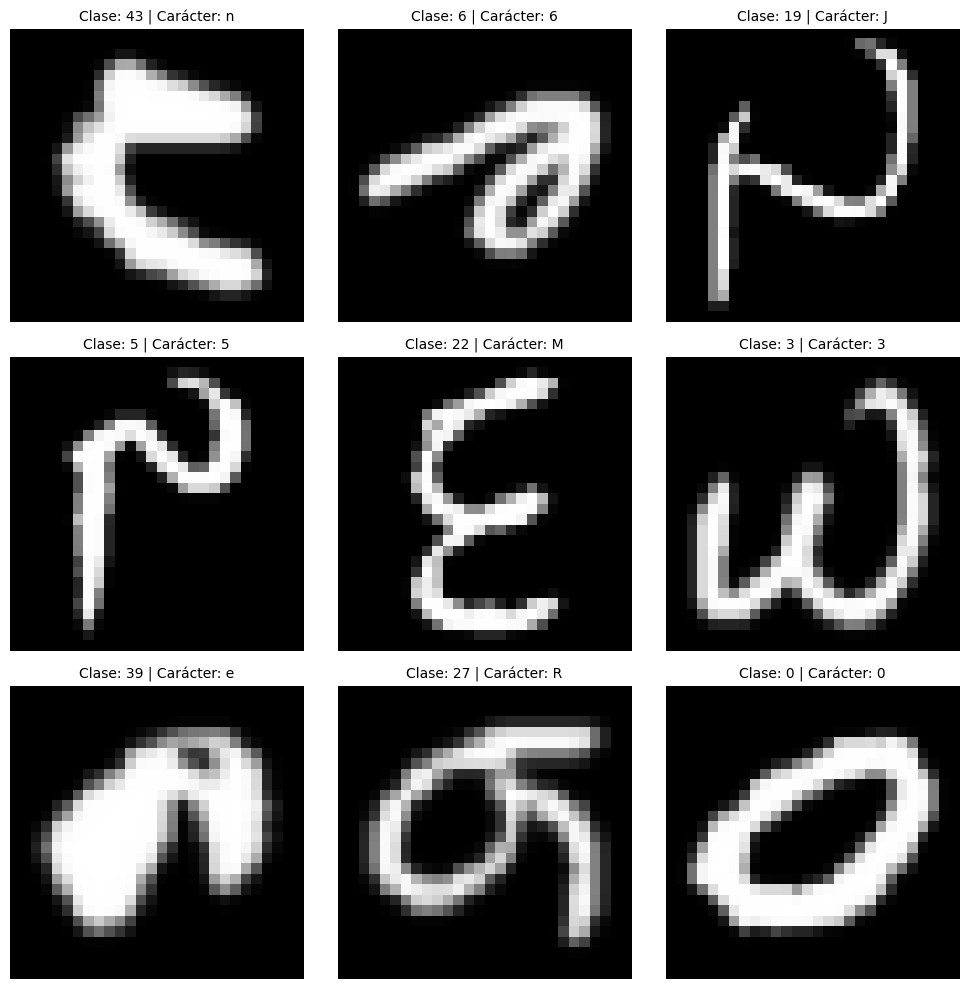

In [5]:
utils.plot_random_emnist_samples(X_images, y_images, n_samples=9)

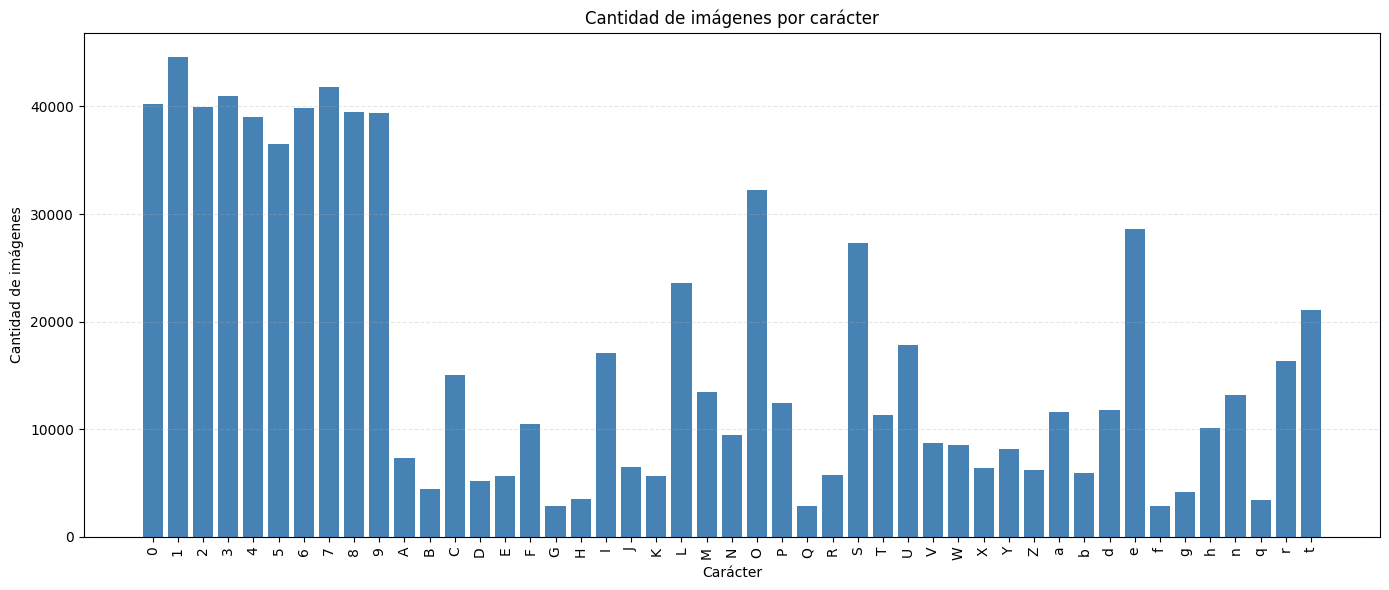

In [6]:
utils.plot_emnist_character_distribution(y_images)

In [7]:
X_train_norm, y_train, X_val_norm, y_val, X_test_norm, y_test = data_split.split_train_val_test_and_normalize(X_images, y_images, seed=42)

print(f"Tamaño Train: {X_train_norm.shape[0]} muestras")
print(f"Tamaño Validación: {X_val_norm.shape[0]} muestras")
print(f"Tamaño Test: {X_test_norm.shape[0]} muestras")
print(f"Rango de datos normalizados: Min={X_train_norm.min()}, Max={X_train_norm.max()}")

Tamaño Train: 566688 muestras
Tamaño Validación: 121433 muestras
Tamaño Test: 121434 muestras
Rango de datos normalizados: Min=0.0, Max=1.0


## 2. Implementación y Entrenamiento de una Red Neuronal Básica

In [8]:
# Aplanamos las imágenes. La red MLP espera vectores 1D como entrada,
# por lo que pasamos de (N, 28, 28) a (N, 784)
X_train_flat = X_train_norm.reshape(X_train_norm.shape[0], -1)
X_val_flat = X_val_norm.reshape(X_val_norm.shape[0], -1)
X_test_flat = X_test_norm.reshape(X_test_norm.shape[0], -1)

In [9]:
# Entrada: 784 nodos (28x28)
# Capas ocultas: 128 y 64 nodos
# Salida: 47 nodos (clases de EMNIST)
architecture_M0 = [784, 128, 64, 47]

M0 = MLP(architecture_M0)

EPOCHS = 100
LEARNING_RATE = 0.1

print("Iniciando entrenamiento del modelo M0...")
train_loss_M0, val_loss_M0 = M0.train(X_train_flat, y_train, X_val_flat, y_val, EPOCHS, LEARNING_RATE)

Iniciando entrenamiento del modelo M0...
Época 000 | Train Loss: 4.1354 | Val Loss: 3.8987
Época 010 | Train Loss: 3.3419 | Val Loss: 3.2956
Época 020 | Train Loss: 2.8914 | Val Loss: 2.8568
Época 030 | Train Loss: 2.5521 | Val Loss: 2.5279
Época 040 | Train Loss: 2.2944 | Val Loss: 2.2777
Época 050 | Train Loss: 2.0959 | Val Loss: 2.0843
Época 060 | Train Loss: 1.9402 | Val Loss: 1.9322
Época 070 | Train Loss: 1.8152 | Val Loss: 1.8096
Época 080 | Train Loss: 1.7126 | Val Loss: 1.7089
Época 090 | Train Loss: 1.6274 | Val Loss: 1.6255
Época 099 | Train Loss: 1.6619 | Val Loss: 1.6422


### Explicación de la implementación

La red neuronal usada en este punto es un **MLP (Multilayer Perceptron)** totalmente conectado. En el notebook se crea con `arquitectura_M0 = [784, 128, 64, 47]`:

- **784 nodos de entrada**: cada imagen de 28x28 píxeles se aplana con `reshape` para transformarse en un vector de 784 valores.
- **2 capas ocultas**: la primera con 128 neuronas y la segunda con 64 neuronas.
- **47 nodos de salida**: uno por cada clase del dataset EMNIST.

### 1. Entrada de los datos
Antes de entrenar, las imágenes se normalizan y luego se convierten de matriz a vector. Esto permite que la red reciba una fila por muestra, algo necesario para trabajar con capas densas. Cada vector representa la imagen completa en una sola dimensión.

### 2. Inicialización de pesos y sesgos
En la clase `MLP`, cada capa aprende dos parámetros:

- **Pesos (`W`)**: controlan la fuerza de la conexión entre neuronas.
- **Sesgos (`b`)**: permiten desplazar la activación de cada neurona.

Los pesos se inicializan con una estrategia tipo **He initialization**, que ayuda a mantener estables las activaciones al comienzo del entrenamiento y evita que la señal se apague o explote en redes con ReLU.

### 3. Forward pass
En cada capa oculta la red calcula:

$$Z = A \cdot W + b$$

Luego aplica la función **ReLU**:

$$\mathrm{ReLU}(Z) = \max(0, Z)$$

Esto introduce no linealidad, lo que permite que la red aprenda patrones complejos.

### 4. Capa de salida
La última capa no usa ReLU, sino **softmax**. Primero genera la "puntuación" o la confianza pura que la red le asigna a cada clase en base a los pesos que aprendió y después los transforma en probabilidades para las 47 clases.

La softmax convierte los valores de salida en una distribución de probabilidad, de modo que todas las probabilidades sumen 1. En la implementación se resta el máximo de cada fila antes de exponentiar para mejorar la estabilidad numérica.

### 5. Función de pérdida
El entrenamiento usa **cross-entropy**, que compara las probabilidades predichas con las etiquetas reales en formato one-hot. Esta pérdida penaliza más cuando la red asigna baja probabilidad a la clase correcta.

### 6. Backpropagation
Durante el retroceso del error, la red calcula cómo cambia la pérdida respecto de cada peso y sesgo. En la salida, la combinación **softmax + cross-entropy** simplifica el gradiente a:

$$dZ = \hat{Y} - Y$$

Después ese error se propaga hacia atrás capa por capa usando la regla de la cadena. En las capas ocultas se multiplica por la derivada de ReLU, que vale 1 cuando la activación fue positiva y 0 cuando fue negativa.

### 7. Actualización de parámetros
Con los gradientes ya calculados, la red actualiza pesos y sesgos con descenso por gradiente:

$$\theta := \theta - \alpha \cdot \nabla\theta$$

donde `\alpha` es el **learning rate**. En este caso, el entrenamiento del modelo base usa `LEARNING_RATE = 0.1` y `EPOCHS = 100`.

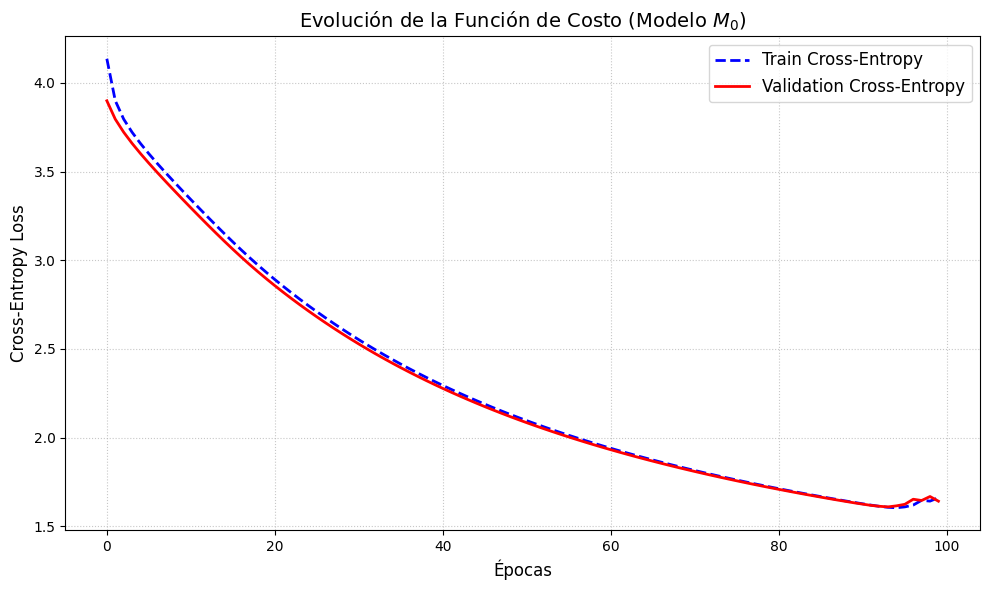

In [10]:
utils.plot_loss_curves(
    train_loss_M0,
    val_loss_M0,
    title='Evolución de la Función de Costo (Modelo $M_0$)'
)

In [11]:
metrics_m0 = metrics.build_metrics_report(
    M0,
    X_train_flat,
    y_train,
    X_val_flat,
    y_val,
    num_classes=47,
    model_name='M0'
)

metrics_m0[['Train', 'Validation']] = metrics_m0[['Train', 'Validation']].round(4)
metrics_m0

,Métrica,Train,Validation,Modelo
0,Cross-Entropy,1.6390,1.6422,M0
1,Accuracy,0.5623,0.5606,M0
2,F1-Score Macro,0.3382,0.3384,M0


Podemos notar que Accuracy y F1 reportan valores casi idénticos en el entrenamiento y en validación. Sin embargo, estos valores son bajos, lo cual nos indica que el modelo M0 no estaría obteniendo la capacidad de capturar la  complejidad del dataset (underfitting).

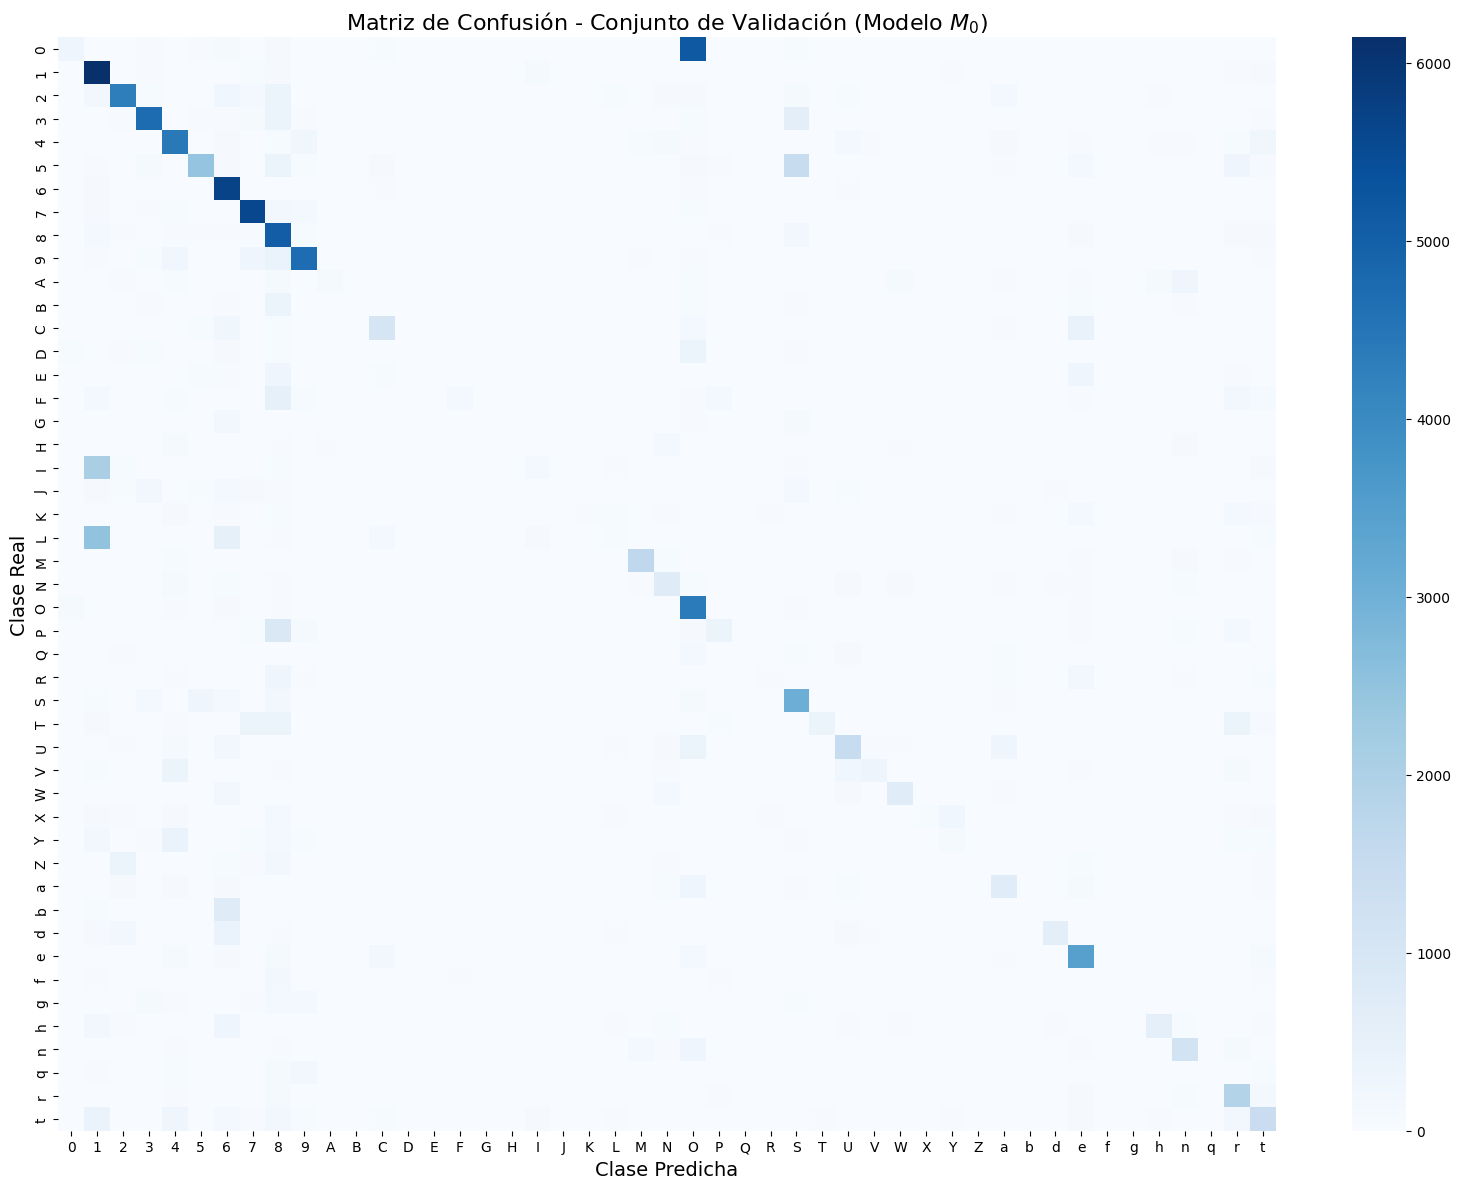

In [12]:
y_pred_val = metrics.predict(M0, X_val_flat)
cm_val = metrics.compute_confusion_matrix(y_val, y_pred_val, num_classes=47)

utils.plot_confusion_matrix_with_characters(
    cm_val,
    title='Matriz de Confusión - Conjunto de Validación (Modelo $M_0$)'
)

Acá podemos apreciar como el modelo predice relativamente bien las clases más distinguibles y que no tienen algún carácter similar. Pero las clases que sí los tienen, ahí es donde el modelo falla y se confunde. Por ejemplo, es notorio es caso entre 0 y O, M0 tiende a predecir todo como O. 

## 3. Implementación y Entrenamiento de una Red Neuronal Avanzada


[Mini-batch] ...
[Mini-batch] Config: Arq=784 -> 128 -> 64 -> 47 | Opt=sgd | LR=0.1 | Batch=256 | L2=0.0 | Scheduler=exponential | Patience=5
--> Train Loss: 0.3316 | Val Loss: 0.3673 | Tiempo: 28.9 s

[Adam] ...
[Adam] Config: Arq=784 -> 128 -> 64 -> 47 | Opt=adam | LR=0.001 | Batch=Full | L2=0.0 | Scheduler=exponential | Patience=5
--> Train Loss: 2.8365 | Val Loss: 2.8079 | Tiempo: 11.2 s

[Scheduler lineal] ...
[Scheduler lineal] Config: Arq=784 -> 128 -> 64 -> 47 | Opt=sgd | LR=0.1 | Batch=Full | L2=0.0 | Scheduler=linear | Patience=5
--> Train Loss: 3.4453 | Val Loss: 3.4468 | Tiempo: 11.2 s

[Scheduler exponencial] ...
[Scheduler exponencial] Config: Arq=784 -> 128 -> 64 -> 47 | Opt=sgd | LR=0.1 | Batch=Full | L2=0.0 | Scheduler=exponential | Patience=5
--> Train Loss: 3.2727 | Val Loss: 3.2578 | Tiempo: 11.2 s

[L2] ...
[L2] Config: Arq=784 -> 128 -> 64 -> 47 | Opt=sgd | LR=0.1 | Batch=Full | L2=0.01 | Scheduler=exponential | Patience=5
--> Train Loss: 3.3582 | Val Loss: 3.344

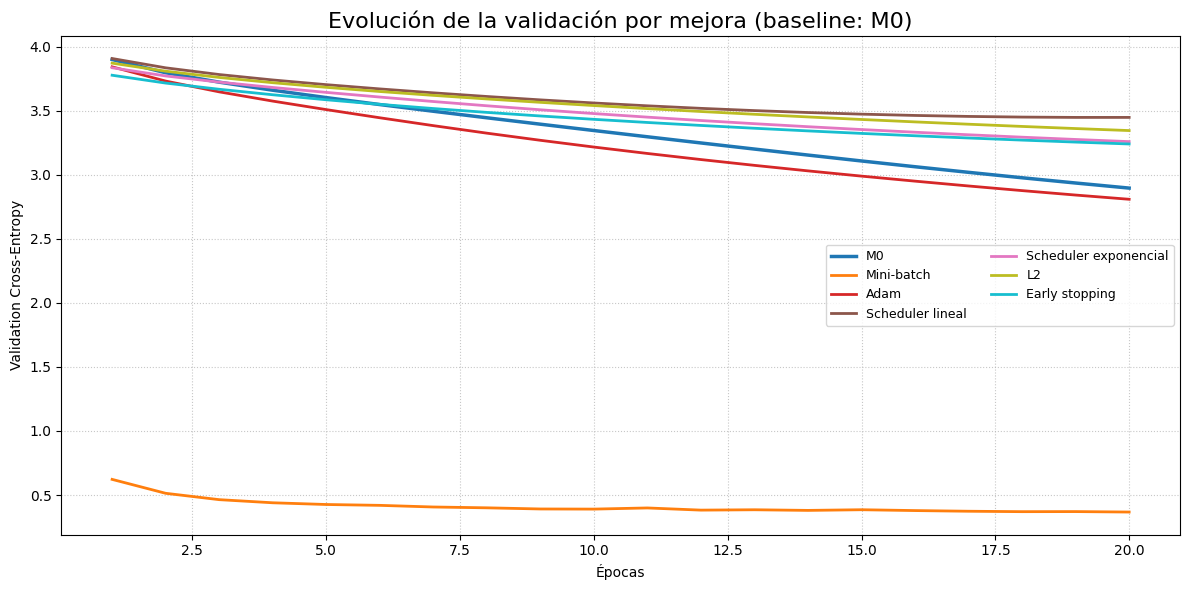

,Experimento,Scheduler,Batch Size,Optimizer,L2,Patience,Épocas ejecutadas,Tiempo (s),Train Loss,Val Loss,Train Acc,Val Acc,Train F1,Val F1,Arq
0,M0,sgd,Full,sgd,0.00,-,100,NaN,1.6619,1.6422,0.5623,0.5606,0.3382,0.3384,"[784, 128, 64, 47]"
1,Mini-batch,exponential,256,sgd,0.00,5,20,28.8589,0.3316,0.3673,0.8860,0.8728,0.8538,0.8360,784 -> 128 -> 64 -> 47
2,Adam,exponential,Full,adam,0.00,5,20,11.2471,2.8365,2.8079,0.3044,0.3016,0.1183,0.1177,784 -> 128 -> 64 -> 47
3,Scheduler lineal,linear,Full,sgd,0.00,5,20,11.2435,3.4453,3.4468,0.1764,0.1772,0.0419,0.0425,784 -> 128 -> 64 -> 47
4,Scheduler exponencial,exponential,Full,sgd,0.00,5,20,11.2384,3.2727,3.2578,0.2290,0.2288,0.0789,0.0791,784 -> 128 -> 64 -> 47
5,L2,exponential,Full,sgd,0.01,5,20,11.2399,3.3582,3.3441,0.2079,0.2074,0.0603,0.0599,784 -> 128 -> 64 -> 47
6,Early stopping,exponential,Full,sgd,0.00,5,20,11.2309,3.2533,3.2395,0.2278,0.2265,0.0723,0.0723,784 -> 128 -> 64 -> 47


In [16]:
# Ablation study sobre M0
importlib.reload(metrics)
X_train_gpu = cp.asarray(X_train_flat)
X_val_gpu = cp.asarray(X_val_flat)
y_train_gpu = cp.asarray(y_train)
y_val_gpu = cp.asarray(y_val)

baseline_metrics_m0 = metrics_m0.set_index('Métrica')
reference_metrics_m0 = {
    'Train Loss': float(train_loss_M0[-1]),
    'Val Loss': float(val_loss_M0[-1]),
    'Train Acc': float(baseline_metrics_m0.loc['Accuracy', 'Train']),
    'Val Acc': float(baseline_metrics_m0.loc['Accuracy', 'Validation']),
    'Train F1': float(baseline_metrics_m0.loc['F1-Score Macro', 'Train']),
    'Val F1': float(baseline_metrics_m0.loc['F1-Score Macro', 'Validation']),
    'Scheduler': 'sgd',
    'Batch Size': 'Full',
    'Optimizer': 'sgd',
    'L2': 0.0,
    'Patience': '-',
    'Arquitectura': architecture_M0
}

improvement_experiments = [
    {'name': 'Mini-batch', 'scheduler_type': 'exponential', 'batch_size': 256, 'optimizer': 'sgd', 'l2': 0.0, 'patience': 5},
    {'name': 'Adam', 'scheduler_type': 'exponential', 'batch_size': None, 'optimizer': 'adam', 'l2': 0.0, 'patience': 5},
    {'name': 'Scheduler lineal', 'scheduler_type': 'linear', 'batch_size': None, 'optimizer': 'sgd', 'l2': 0.0, 'patience': 5},
    {'name': 'Scheduler exponencial', 'scheduler_type': 'exponential', 'batch_size': None, 'optimizer': 'sgd', 'l2': 0.0, 'patience': 5},
    {'name': 'L2', 'scheduler_type': 'exponential', 'batch_size': None, 'optimizer': 'sgd', 'l2': 0.01, 'patience': 5},
    {'name': 'Early stopping', 'scheduler_type': 'exponential', 'batch_size': None, 'optimizer': 'sgd', 'l2': 0.0, 'patience': 5},
]

ablation_df, ablation_histories = metrics.compare_training_improvements(
    model_factory=lambda: advanced.MLP_Advanced([784, 128, 64, 47]),
    experiments=improvement_experiments,
    X_train=X_train_gpu,
    y_train=y_train_gpu,
    X_val=X_val_gpu,
    y_val=y_val_gpu,
    reference_metrics=reference_metrics_m0,
    epochs=20,
    learning_rate=0.1,
    num_classes=47,
    reference_name='M0',
    return_histories=True,
)

utils.plot_ablation_loss_curves(val_loss_M0, ablation_histories, baseline_name='M0')

ablation_df.round(4)

Al comparar cada experimento contra el modelo base, el gráfico deja en evidencia que la mejor optimización es la implementación de Mini-Batch, donde la red aprende mucho más rápido y consumiendo menos recursos. Adam también muestra una mejora ya que maneja eficientemente la velocidad de aprendizaje. 

Adam fue entrenado con un learning rate de 0.001, a diferencias de los otros que trabajon con 0.1. Este es un valor relativamente alto para Adam, al darle un paso tan grande, los gradientes "explotaban", rebotaban fuera del mínimo de la función de costo y destruyeron los pesos de la red.

Los experimentos restantes, al ser evaluados bajo la restricción del Full-Batch, mostraron resultados algo pobres.

### Explicación de la implementación

En este punto se implementa una versión más completa de la red neuronal, llamada `MLP_Advanced`, y se usa una **búsqueda exhaustiva de hiperparámetros** para encontrar la mejor configuración posible sobre el conjunto de validación.

### 1. Qué se busca optimizar

- **Arquitectura**: se prueban algunas variantes, redes más anchas y más profundas.
- **Optimizador**: se comparan `sgd` y `adam`, luego solo me quedo con adam.
- **Learning rate**: se fija en `0.001` para todas las pruebas finales.
- **Batch size**.
- **Regularización L2**.

### 2. Qué hace `MLP_Advanced`
Esta clase mantiene la estructura de una red totalmente conectada, pero agrega mejoras importantes respecto del modelo base:

- **Inicialización de He** para los pesos, igual que en el modelo anterior.
- **ReLU** en las capas ocultas para introducir no linealidad.
- **Softmax** en la salida para obtener probabilidades por clase.
- **Cross-entropy con L2** para penalizar errores y evitar pesos demasiado grandes.
- **Adam o SGD** como estrategias de actualización.

### 3. Cómo entrena cada configuración
Para cada combinación, se crea una red nueva desde cero. Después se entrena con la función `train`, que hace lo siguiente en cada época:

1. Mezcla los datos de entrenamiento.
2. Divide el conjunto en mini-batches según el `batch_size`.
3. Ejecuta el forward pass.
4. Calcula la pérdida con cross-entropy y el término L2.
5. Aplica backpropagation.
6. Actualiza los pesos con SGD o Adam.
7. Evalúa la red en validación.

Además, se usa **learning rate scheduling exponencial**, que reduce progresivamente la tasa de aprendizaje durante el entrenamiento. Esto ayuda a que el modelo haga pasos grandes al principio y ajustes más finos al final.

### 5. Early stopping
La red también incorpora **early stopping**: si la validación no mejora durante varias épocas consecutivas, el entrenamiento se interrumpe antes de llegar al máximo de épocas. Esto evita sobreentrenar configuraciones malas y ahorra tiempo de cómputo.

### 6. Cómo se elige el mejor modelo
Para comparar configuraciones, se toma la **mínima validation loss** obtenida por cada una. La mejor configuración es la que logra el menor valor de pérdida en validación, porque es la que generaliza mejor sobre datos no vistos.

Diseño del último Grid Search 

```python
param_grid = {
    'arquitectura': [
        [784, 256, 128, 47],        
        [784, 256, 128, 64, 47],    
        [784, 512, 256, 128, 47]    
    ],
    'optimizer': ['adam'],          
    'learning_rate': [0.001],       
    'batch_size': [128, 256],       
    'l2': [0.01, 0.001, 0.0001]    
}

In [ ]:
M1_config, historial_grid, df_top5 = grid_search_.grid_search(
    X_train_gpu, y_train_gpu, X_val_gpu, y_val_gpu,
    epochs=40,
    patience=5
)

Iniciando Grid Search. Total de configuraciones a probar: 18
------------------------------------------------------------

[1/18] Probando: Opt=adam, LR=0.001, L2=0.0, Batch=128, Arq=[784, 256, 128, 47]
Época 000 | [Exp] LR: 0.00100 | Train Loss: 0.5578 | Val Loss: 0.4232
Época 005 | [Exp] LR: 0.00078 | Train Loss: 0.2925 | Val Loss: 0.3368
Época 010 | [Exp] LR: 0.00061 | Train Loss: 0.2498 | Val Loss: 0.3458

¡Early stopping en la época 13!
--> Val Loss: 0.3342 | Tiempo: 204.5 seg
🏆 ¡NUEVO MEJOR MODELO!

[2/18] Probando: Opt=adam, LR=0.001, L2=0.001, Batch=128, Arq=[784, 256, 128, 47]
Época 000 | [Exp] LR: 0.00100 | Train Loss: 0.5642 | Val Loss: 0.4149
Época 005 | [Exp] LR: 0.00078 | Train Loss: 0.3095 | Val Loss: 0.3360
Época 010 | [Exp] LR: 0.00061 | Train Loss: 0.2738 | Val Loss: 0.3357

¡Early stopping en la época 13!
--> Val Loss: 0.3319 | Tiempo: 218.1 seg
🏆 ¡NUEVO MEJOR MODELO!

[3/18] Probando: Opt=adam, LR=0.001, L2=0.0001, Batch=128, Arq=[784, 256, 128, 47]
Época 000 | [Exp

Las 5 mejores configuraciones utilizan la arquitectura 784 -> 512 -> 256 -> 128 -> 47. EMNIST ByMerge es un dataset complejo con 47 clases que requiere una gran capacidad de representación (muchos parámetros) para capturar sutilezas entre caracteres similares.

La combinación ganadora se quedó con Adam (LR=0.001) y Batch Size 256 como la configuración óptima. Adam prospera en entornos de Mini-Batch logrando descender rápidamente hacia el mínimo global. 

In [18]:
print("Iniciando entrenamiento del modelo M1...")

M1_config = {
    'arquitectura': [784, 512, 256, 128, 47],
    'optimizer': 'adam',
    'learning_rate': 0.001,
    'batch_size': 256,
    'l2': 0.001
}

M1 = advanced.MLP_Advanced(M1_config['arquitectura'])

t_start = time.time()
train_loss_m1_gpu, val_loss_m1_gpu = M1.train(
    X_train_gpu, y_train_gpu, X_val_gpu, y_val_gpu,
    epochs=100,
    learning_rate=M1_config['learning_rate'],
    batch_size=M1_config['batch_size'],
    optimizer=M1_config['optimizer'],
    l2=M1_config['l2'],
    patience=10,
    scheduler_type='exponential',
    decay_rate=0.05,
    final_lr=1e-5
)
t_m1 = time.time() - t_start

train_loss_M1 = np.array([float(x) for x in train_loss_m1_gpu])
val_loss_M1 = np.array([float(x) for x in val_loss_m1_gpu])

print(f"\nM1 entrenado en {t_m1:.1f} segundos")
print(f"  • Loss Train Final: {train_loss_M1[-1]:.4f}")
print(f"  • Loss Val Final: {val_loss_M1[-1]:.4f}")


Iniciando entrenamiento del modelo M1...
Época 000 | [Exp] LR: 0.00100 | Train Loss: 0.5402 | Val Loss: 0.3990
Época 005 | [Exp] LR: 0.00078 | Train Loss: 0.2741 | Val Loss: 0.3268
Época 010 | [Exp] LR: 0.00061 | Train Loss: 0.2268 | Val Loss: 0.3358
Época 015 | [Exp] LR: 0.00047 | Train Loss: 0.1953 | Val Loss: 0.3651

¡Early stopping en la época 16!

M1 entrenado en 59.1 segundos
  • Loss Train Final: 0.1904
  • Loss Val Final: 0.3720


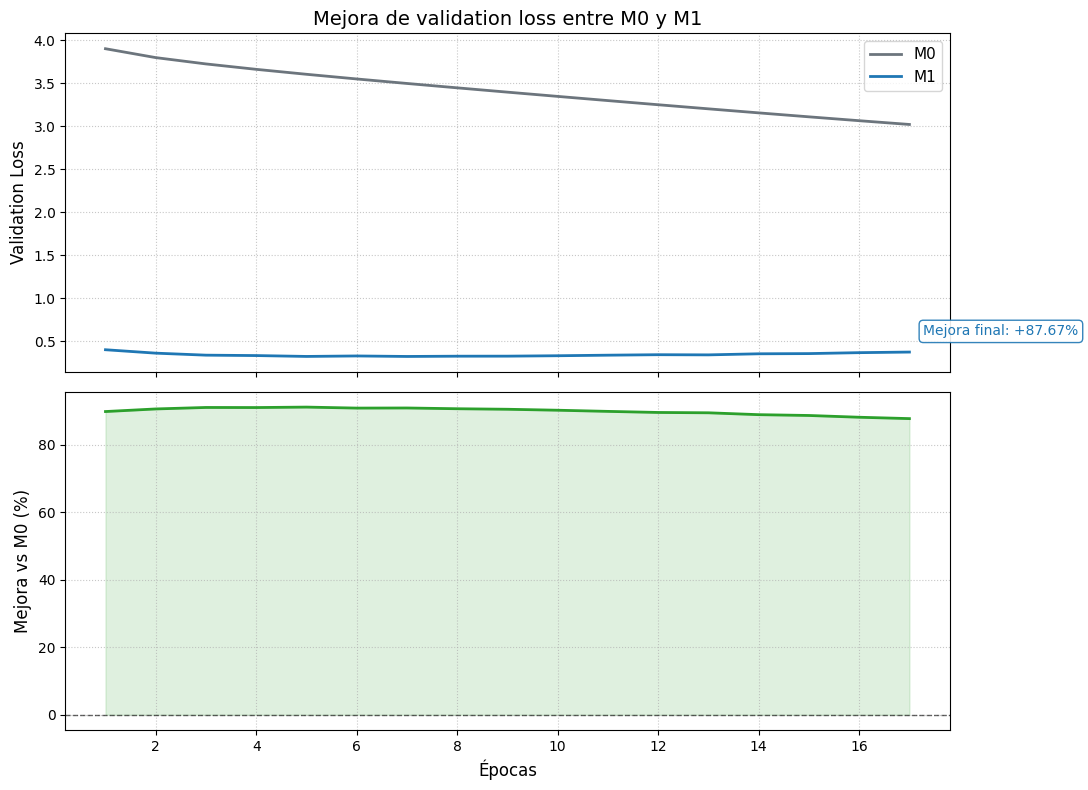

In [19]:
# Comparar visualmente la mejora de validation loss entre M0 y M1
importlib.reload(utils)
utils.plot_validation_loss_improvement(
    val_loss_M0,
    val_loss_M1,
    baseline_label='M0',
    improved_label='M1',
)

M1 superó completamente a M0, reportando Accuracy y F1 mucho mayor y loss menor. 

,Métrica,M0,M1,Cambio absoluto,Cambio % vs M0
0,Cross-Entropy,1.6422,0.3720,-1.2702,-77.35
1,Accuracy,0.5606,0.8859,0.3253,58.03
2,F1-Score Macro,0.3384,0.8601,0.5217,154.17


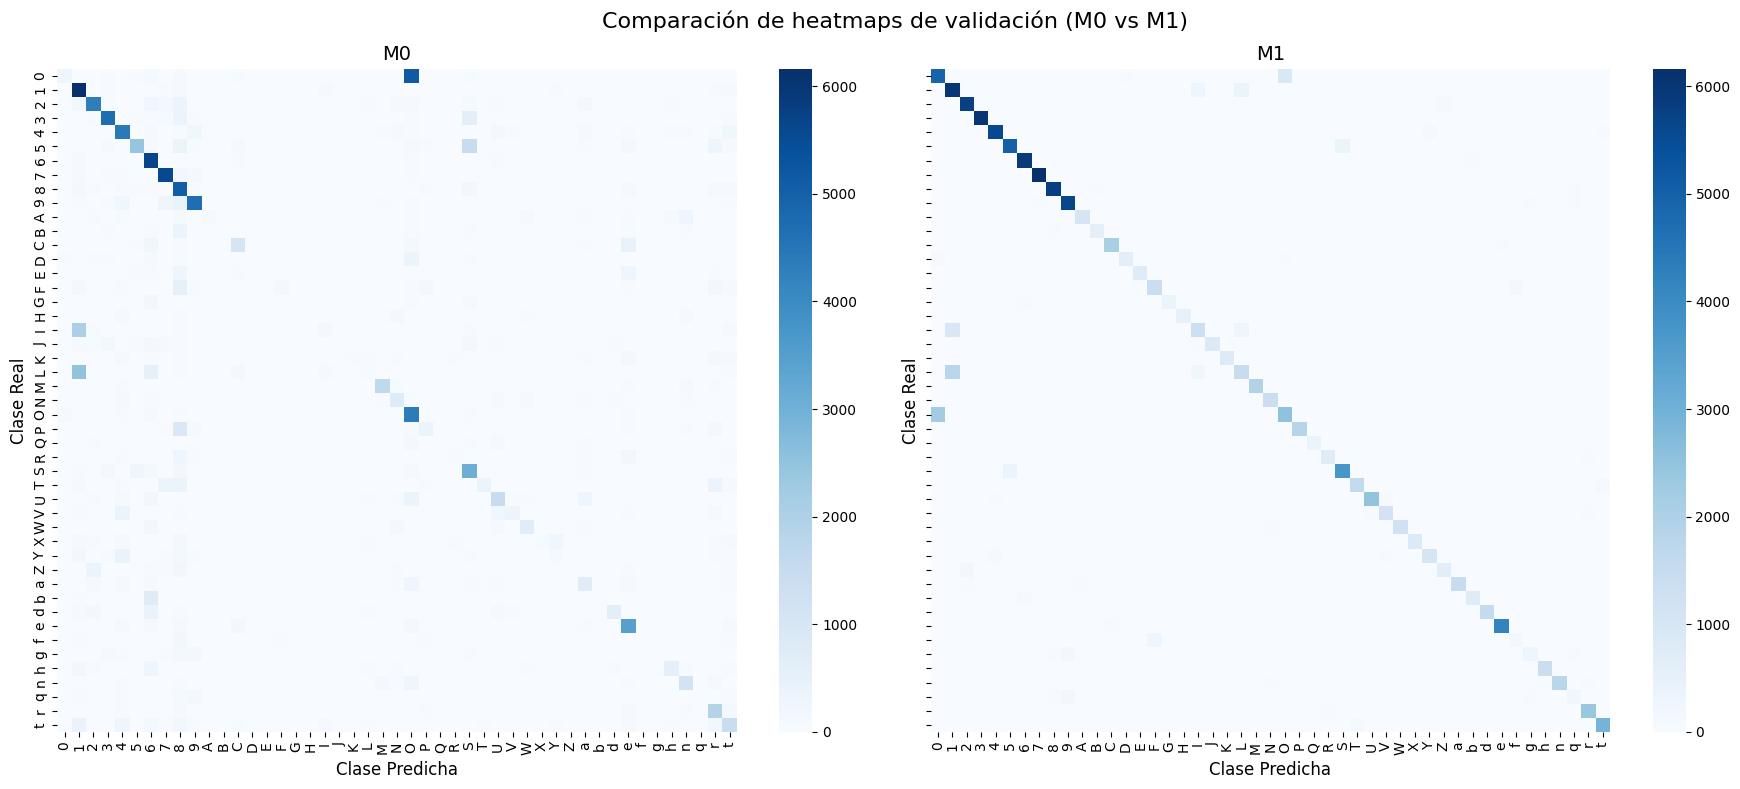

In [20]:
# Resumen comparativo de métricas y heatmaps entre M0 y M1
importlib.reload(metrics)
importlib.reload(utils)
metrics_m1 = metrics.build_metrics_report(
    M1,
    X_train_flat,
    y_train,
    X_val_flat,
    y_val,
    num_classes=47,
    model_name='M1',
)
metrics_m1[['Train', 'Validation']] = metrics_m1[['Train', 'Validation']].round(4)

metrics_m0_val = metrics_m0.set_index('Métrica')['Validation']
metrics_m1_val = metrics_m1.set_index('Métrica')['Validation']
metricas_comparadas = pd.DataFrame({
    'M0': metrics_m0_val,
    'M1': metrics_m1_val,
})
metricas_comparadas['Cambio absoluto'] = metricas_comparadas['M1'] - metricas_comparadas['M0']
metricas_comparadas['Cambio % vs M0'] = 100 * metricas_comparadas['Cambio absoluto'] / metricas_comparadas['M0']
metricas_comparadas = metricas_comparadas.reset_index().rename(columns={'index': 'Métrica'})
metricas_comparadas = metricas_comparadas[['Métrica', 'M0', 'M1', 'Cambio absoluto', 'Cambio % vs M0']]
metricas_comparadas[['M0', 'M1', 'Cambio absoluto']] = metricas_comparadas[['M0', 'M1', 'Cambio absoluto']].round(4)
metricas_comparadas['Cambio % vs M0'] = metricas_comparadas['Cambio % vs M0'].round(2)
display(metricas_comparadas)

pred_val_m0 = metrics.predict(M0, X_val_flat)
pred_val_m1 = metrics.predict(M1, X_val_flat)
cm_val_m0 = metrics.compute_confusion_matrix(y_val, pred_val_m0, num_classes=47)
cm_val_m1 = metrics.compute_confusion_matrix(y_val, pred_val_m1, num_classes=47)

utils.plot_confusion_matrix_comparison(
    cm_val_m0,
    cm_val_m1,
    baseline_label='M0',
    improved_label='M1',
    title='Comparación de heatmaps de validación (M0 vs M1)',
)

Viendo esta comparación, se aprecia como M1 presenta una diagonal mucho más completa, logrando predecir correctamente caracteres en los cuales M0 se confundía.

## 4. Desarrollo de una Red Neuronal con PyTorch

### Explicación de la implementación

Primero se implementa un modelo equivalente al anterior (`M2`) para validar resultados, y luego un modelo avanzado (`M3`) incorporando técnicas mediante una **búsqueda exhaustiva de hiperparámetros**.

### 1. Qué se busca optimizar en M3

- **Arquitectura**.
- **Activación**: funciones como `LeakyReLU`, `SiLU` (Swish) y `GELU`.
- **Tasa de Dropout**: 20% y 40%.
- **Regularización L2**.

### 2. Cómo entrena cada configuración en PyTorch
Para cada combinación, se crea una red nueva desde cero en el dispositivo activo. El entrenamiento se gestiona con la función `train_pytorch`, que realiza lo siguiente en cada época:
1. **Manejo de DataLoaders**: automatiza la mezcla (*shuffle*) y división de los tensores en mini-batches de forma eficiente.
2. **Ciclo de entrenamiento (`model.train()`)**: activa componentes específicos como el Dropout. Por cada batch, calcula la pasada hacia adelante (*forward*), evalúa la pérdida y actualiza los pesos de forma automática mediante: `optimizer.zero_grad()` (limpieza de gradientes), `loss.backward()` (retropropagación automática) y `optimizer.step()` (ajuste de parámetros).
3. **Regularización L2 integrada**: el término de penalización se delega directamente al optimizador configurando el parámetro `weight_decay`.
4. **Fase de validación (`model.eval()`)**: apaga el Dropout para usar el 100% de la capacidad de la red, y utiliza el contexto `with torch.no_grad()` para deshabilitar el cálculo de derivadas, ahorrando memoria RAM de la GPU y acelerando el proceso.

Además, incorpora el **learning rate scheduling exponencial** (`ExponentialLR`), que reduce la tasa de aprendizaje suavemente tras cada época. También, al igual que en NumPy, se incorpora **early stopping**. 

### 3. Cómo se elige el mejor modelo
Se toma la **mínima validation loss** obtenida por cada una. La combinación ganadora es aquella que logra el menor valor de pérdida en validación.

In [21]:
importlib.reload(pytorch)
M2, train_loss_M2, val_loss_M2 = pytorch.train_pytorch(
    X_train_flat, y_train, X_val_flat, y_val, config=M1_config, epochs=100
)

Corriendo en: cuda

Iniciando el entrenamiento... (Modelo: MLP_PyTorch)
Época 000 | Train Loss: 0.6629 | Val Loss: 0.4973
Época 005 | Train Loss: 0.3907 | Val Loss: 0.3996
Época 010 | Train Loss: 0.3706 | Val Loss: 0.3784
Época 015 | Train Loss: 0.3594 | Val Loss: 0.3678
Época 020 | Train Loss: 0.3513 | Val Loss: 0.3589
Época 025 | Train Loss: 0.3449 | Val Loss: 0.3547
Época 030 | Train Loss: 0.3397 | Val Loss: 0.3564
Época 035 | Train Loss: 0.3357 | Val Loss: 0.3495
Época 040 | Train Loss: 0.3323 | Val Loss: 0.3484
Época 045 | Train Loss: 0.3295 | Val Loss: 0.3451
Época 050 | Train Loss: 0.3273 | Val Loss: 0.3437
Época 055 | Train Loss: 0.3255 | Val Loss: 0.3429
Época 060 | Train Loss: 0.3240 | Val Loss: 0.3428
Época 065 | Train Loss: 0.3227 | Val Loss: 0.3421
Época 070 | Train Loss: 0.3216 | Val Loss: 0.3414
Época 075 | Train Loss: 0.3208 | Val Loss: 0.3409
Época 080 | Train Loss: 0.3202 | Val Loss: 0.3406
Época 085 | Train Loss: 0.3197 | Val Loss: 0.3408
Época 090 | Train Loss: 0.31

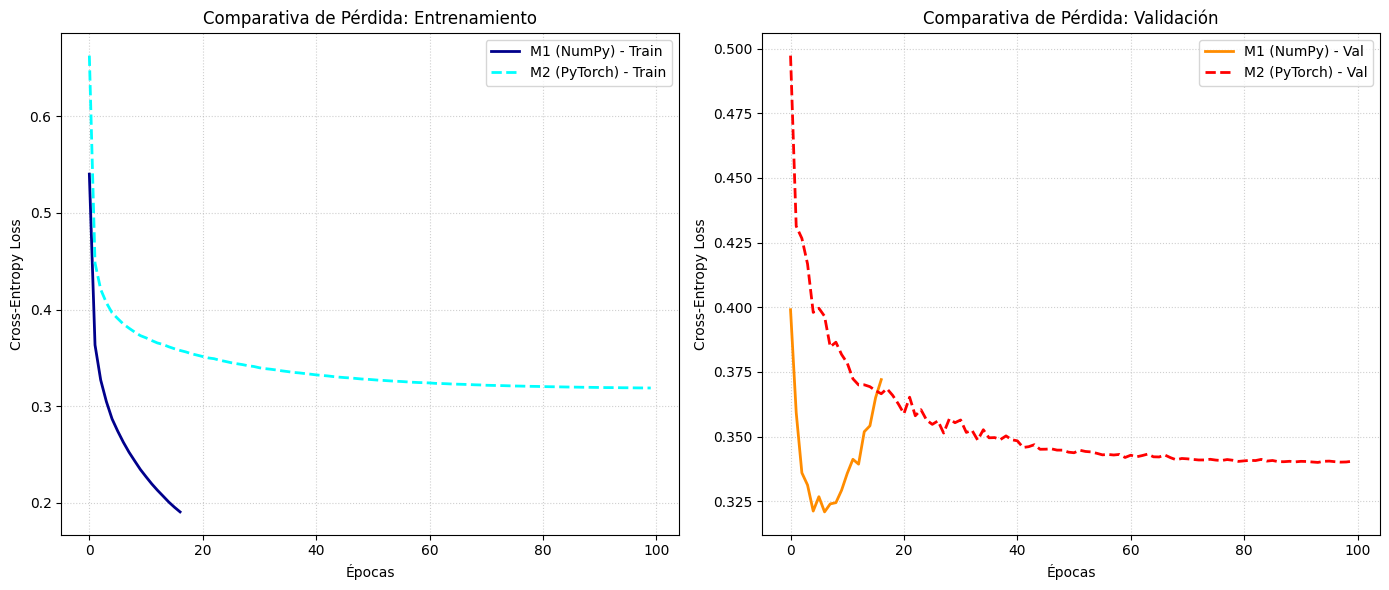

M1 (NumPy)   -> Pérdida Mínima en Validación: 0.3209
M2 (PyTorch) -> Pérdida Mínima en Validación: 0.3400
Diferencia absoluta: 0.01914


In [22]:
importlib.reload(utils)

utils.plot_numpy_pytorch_loss_comparison(
    train_loss_M1,
    train_loss_M2,
    val_loss_M1,
    val_loss_M2,
    model_1_label='M1 (NumPy)',
    model_2_label='M2 (PyTorch)',
)

Verificamos que la diferencia entre el modelo "from scratch" y el modelo con PyTorch es bastante chica. 

Diseño del último Grid Search 

```python
param_grid_m3 = {
    'arquitectura': [
        [784, 256, 128, 64, 47],           
        [784, 512, 256, 128, 47]    
    ],
    'activacion': ['leaky_relu', 'silu', 'gelu'],
    'dropout_rate': [0.2, 0.4],
    'l2': [0.0, 0.0001]      
}

In [ ]:
M3_config = pytorch.grid_search_pytorch_m3(X_train_flat, y_train, X_val_flat, y_val, M1_config)

Iniciando búsqueda de M3 con 24 combinaciones ...

[1/24] Probando: Arq=[784, 256, 128, 64, 47], Act=leaky_relu, Drop=0.2

Iniciando el entrenamiento... (Modelo: MLP_Advanced_PyTorch)
Época 000 | Train Loss: 0.8697 | Val Loss: 0.4732
Época 005 | Train Loss: 0.4418 | Val Loss: 0.3541
Época 010 | Train Loss: 0.4050 | Val Loss: 0.3348
Época 015 | Train Loss: 0.3853 | Val Loss: 0.3262
Época 020 | Train Loss: 0.3722 | Val Loss: 0.3201
Época 025 | Train Loss: 0.3631 | Val Loss: 0.3168
Época 030 | Train Loss: 0.3561 | Val Loss: 0.3150
Época 035 | Train Loss: 0.3499 | Val Loss: 0.3133
Época 039 | Train Loss: 0.3471 | Val Loss: 0.3130
--> Val Loss: 0.3130 | Tiempo: 407.6s
🏆 ¡NUEVO MEJOR MODELO!

[2/24] Probando: Arq=[784, 256, 128, 64, 47], Act=leaky_relu, Drop=0.2

Iniciando el entrenamiento... (Modelo: MLP_Advanced_PyTorch)
Época 000 | Train Loss: 0.8885 | Val Loss: 0.4762
Época 005 | Train Loss: 0.4574 | Val Loss: 0.3655
Época 010 | Train Loss: 0.4257 | Val Loss: 0.3412
Época 015 | Train Los

Volvemos a obtener una arquitectura con mayor capacidad paramétrica. 

La función GELU superó a ReLU y a sus variantes. Su curvatura suave alrededor del cero permitió un flujo de gradientes mucho más estable en una red tan profunda.

Al usar un apagado aleatorio del 20% de las neuronas en cada pasada, forzamos a la red a aprender características redundantes y robustas. Esto le permitió entrenar por muchísimas más épocas sin memorizar el set de entrenamiento.

In [ ]:
M3, train_loss_M3, val_loss_M3 = pytorch.train_pytorch(
    X_train_flat, y_train, X_val_flat, y_val, config=M3_config, epochs=100
)


Iniciando el entrenamiento... (Modelo: MLP_Advanced_PyTorch)
Época 000 | Train Loss: 0.6784 | Val Loss: 0.4028
Época 005 | Train Loss: 0.3477 | Val Loss: 0.3155
Época 010 | Train Loss: 0.3211 | Val Loss: 0.2964
Época 015 | Train Loss: 0.3055 | Val Loss: 0.2915
Época 020 | Train Loss: 0.2952 | Val Loss: 0.2813
Época 025 | Train Loss: 0.2870 | Val Loss: 0.2798
Época 030 | Train Loss: 0.2803 | Val Loss: 0.2771
Época 035 | Train Loss: 0.2758 | Val Loss: 0.2737
Época 040 | Train Loss: 0.2726 | Val Loss: 0.2718
Época 045 | Train Loss: 0.2696 | Val Loss: 0.2710
Época 050 | Train Loss: 0.2671 | Val Loss: 0.2699
Época 055 | Train Loss: 0.2647 | Val Loss: 0.2690
Época 060 | Train Loss: 0.2629 | Val Loss: 0.2684
Época 065 | Train Loss: 0.2619 | Val Loss: 0.2688
Época 070 | Train Loss: 0.2608 | Val Loss: 0.2681
Época 075 | Train Loss: 0.2611 | Val Loss: 0.2677
Época 080 | Train Loss: 0.2596 | Val Loss: 0.2672
Época 085 | Train Loss: 0.2597 | Val Loss: 0.2673
Época 090 | Train Loss: 0.2588 | Val L

Corriendo en: cuda
Evaluando modelos en el conjunto de TEST...

--- RESULTADOS FINALES SOBRE CONJUNTO DE TEST ---
       Modelo  Accuracy  F1-Score Macro
    M0 (Base)  0.591968        0.349006
M1 (Avanzado)  0.888425        0.859790
 M2 (PyTorch)  0.883163        0.847153
 M3 (PyTorch)  0.901239        0.877937


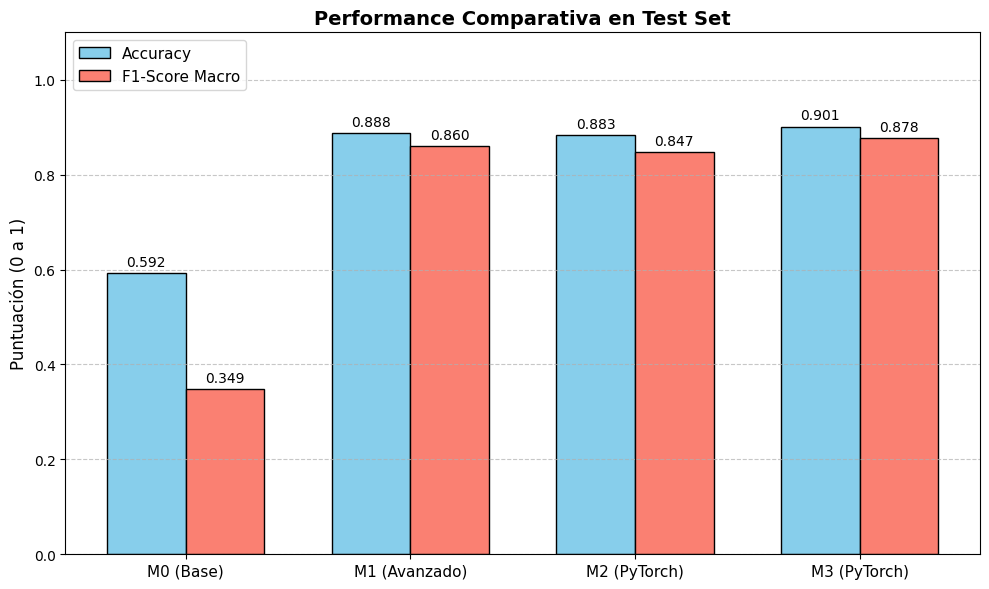

In [ ]:
importlib.reload(pytorch)
importlib.reload(utils)

import gc
torch.cuda.empty_cache()
gc.collect()

print("Evaluando modelos en el conjunto de TEST...")

acc_m0, f1_m0 = pytorch.evaluate_model_numpy(M0, X_test_flat, y_test)

acc_m1, f1_m1 = pytorch.evaluate_model_numpy(M1, X_test_flat, y_test)

acc_m2, f1_m2 = pytorch.evaluate_model_pytorch(M2, X_test_flat, y_test)

acc_m3, f1_m3 = pytorch.evaluate_model_pytorch(M3, X_test_flat, y_test)

resultados = {
    'Modelo': ['M0 (Base)', 'M1 (Avanzado)', 'M2 (PyTorch)', 'M3 (PyTorch)'],
    'Accuracy': [acc_m0, acc_m1, acc_m2, acc_m3],
    'F1-Score Macro': [f1_m0, f1_m1, f1_m2, f1_m3]
}

df_resultados = pd.DataFrame(resultados)
print("\n--- RESULTADOS FINALES SOBRE CONJUNTO DE TEST ---")
print(df_resultados.to_string(index=False))

utils.plot_metrics_bar_comparison(
    df_resultados,
    title='Performance Comparativa en Test Set',
    figsize=(10, 6),
)

* El modelo base M0 demostró la insuficiencia del enfoque clásico, evidenciando un sesgo hacia ciertas clases y un fallo total en la clasificación general.

* La introducción de mini-batches y el optimizador Adam catapultaron el rendimiento, resolviendo el problema de optimización.

* La inyección de GELU y Dropout logró 90% de Accuracy (0.901) y un F1-Score Macro del 0.878. Esta métrica final es el indicador de que el modelo no solo acierta en general, sino que es altamente competente y equitativo para distinguir las 47 clases del dataset.

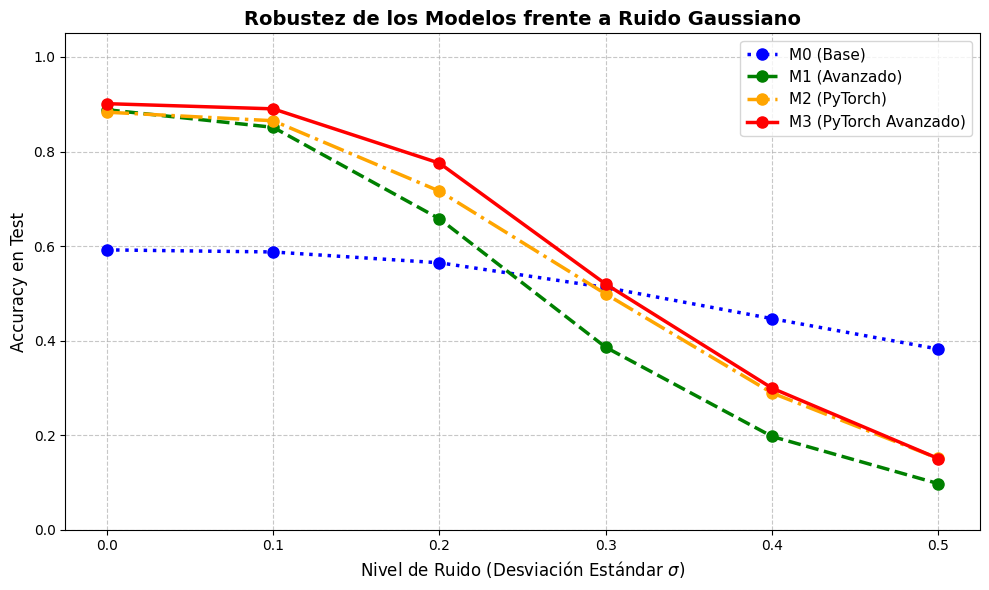

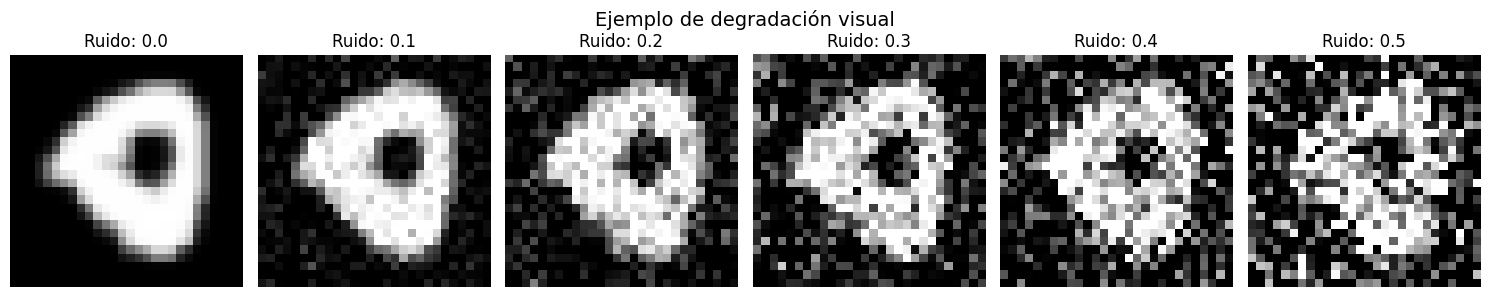

In [ ]:
importlib.reload(utils)

noise = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]

acc_history = {
    'M0 (Base)': [],
    'M1 (Avanzado)': [],
    'M2 (PyTorch)': [],
    'M3 (PyTorch Avanzado)': []
}

for nl in noise:

    X_test_noisy = utils.apply_gaussian_noise(X_test_flat, nl)

    acc0, _ = pytorch.evaluate_model_numpy(M0, X_test_noisy, y_test)
    acc1, _ = pytorch.evaluate_model_numpy(M1, X_test_noisy, y_test)
    acc2, _ = pytorch.evaluate_model_pytorch(M2, X_test_noisy, y_test)
    acc3, _ = pytorch.evaluate_model_pytorch(M3, X_test_noisy, y_test)

    acc_history['M0 (Base)'].append(acc0)
    acc_history['M1 (Avanzado)'].append(acc1)
    acc_history['M2 (PyTorch)'].append(acc2)
    acc_history['M3 (PyTorch Avanzado)'].append(acc3)

utils.plot_noise_robustness(
    acc_history=acc_history,
    niveles_ruido=noise,
    X_test_flat=X_test_flat,
    apply_noise_fn=utils.apply_gaussian_noise,
    title='Robustez de los Modelos frente a Ruido Gaussiano',
    sample_title='Ejemplo de degradación visual',
    x_label=r'Nivel de Ruido (Desviación Estándar $\sigma$)',
)

Los modelos más avanzados (M1, M2 y M3) tienen un buen rendimiento con imágenes limpias, pero sufren una degradación severa a medida que el ruido supera el umbral de $0.2$. Recordemos que estas presentan arquitecturas profundas, con gran cantidad de parámetros, las cuales aprenden características finas y sutiles. Al agregar ruido, este aprendizaje se  destruye, confundiendo la detección de patrones. De todas formas, se ve que M3 es el que resiste mejor al ruido gracias al dropout, generalizando mejor.

M0 es el modelo menos decae frente al ruido pero no significa que sea mejor. El underfitting que presenta el modelo logra capturar formas globales y borrosas.